In [ ]:
'''
Author: Kesar-Chi && momiji0613@163.com
Date: 2026-07-29 09:03:18
LastEditors: Kesar-Chi && momiji0613@163.com
LastEditTime: 2026-07-29 09:03:52
FilePath: \undefinedc:\Users\KesarChi\Desktop\phewas-plot.ipynb
Description: Institute: Beijing Institute Of Genomics, CAS.

Copyright (c) 2026 by ${momiji0613@163.com}, All Rights Reserved. 
'''
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
import sys
sys.path.append('/mnt/m/code/BIGCode/')
from brush import statools
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

root = "/mnt/m/progress/LPA/v2/"
root2 = "/mnt/m/DataSet/LPA/res-phewas"
joint1 = pd.read_csv(root2 + '/res-phewas-cover.csv', sep='\t')


# joint = pd.read_csv(root + "joint-phewas.csv", sep = "\t")
# lpa = pd.read_csv(root + "lpa-phewas.csv", sep = "\t")
# pcsk9 = pd.read_csv(root + "pcsk9-phewas.csv", sep = "\t")
# joint1 = pd.read_csv(root + "joint.csv", sep = "\t") #use
# lpa = pd.read_csv(root + "lpa.csv", sep = "\t")
# pcsk9 = pd.read_csv(root + "pcsk9.csv", sep = "\t")

joint2 = pd.read_csv(root + "global-joint.csv", sep = "\t") # use
lpa = pd.read_csv(root + "global-lpa.csv", sep = "\t")
pcsk9 = pd.read_csv(root + "global-ldl.csv", sep = "\t")

In [32]:
mp_icd = pd.read_csv('/mnt/m/code/BIGCode/pipeline/phewas/ICD10-map.txt', sep='\t')
joint2['name'] = joint2['Trait'].map(mp_icd.set_index('ICD')['Name'])
# merge Trait and name: such as I10.xxx
joint2['name2'] = joint2['Trait'] + '.' + joint2['name']

joint2.head()

,Trait,beta,se,p,name,name2
0,Q67,-0.021738,0.268343,0.935434,Congenital musculoskeletal deformities of head...,Q67.Congenital musculoskeletal deformities of ...
1,N83,-0.028302,0.036833,0.442255,"Noninflammatory disorders of ovary, Fallopian ...","N83.Noninflammatory disorders of ovary, Fallop..."
2,C93,0.115961,0.294601,0.693861,Monocytic leukaemia,C93.Monocytic leukaemia
3,M25,0.018770,0.020072,0.349698,"Other joint disorders, not elsewhere classified","M25.Other joint disorders, not elsewhere class..."
4,Q60,0.094709,0.184768,0.608242,Renal agenesis and other reduction defects of ...,Q60.Renal agenesis and other reduction defects...


In [9]:
joint1['name'] = joint1['Trait'].map(mp_icd.set_index('ICD')['Name'])
joint1.head()

,Trait,beta,se,p,name
0,Q67,0.343023,0.251781,0.173076,Congenital musculoskeletal deformities of head...
1,N83,0.017208,0.036133,0.633904,"Noninflammatory disorders of ovary, Fallopian ..."
2,C93,-0.040542,0.298382,0.891922,Monocytic leukaemia
3,M25,0.000347,0.019738,0.985976,"Other joint disorders, not elsewhere classified"
4,Q60,-0.178595,0.179656,0.320177,Renal agenesis and other reduction defects of ...


In [29]:
joint2[(joint2['p']<0.05/joint2.shape[0]) & (joint2['beta'].abs() < 10)]

,Trait,beta,se,p,name
100,I10,-0.053501,0.010557,4.023202e-07,Essential (primary) hypertension
131,I73,-0.251225,0.032735,1.660214e-14,Other peripheral vascular diseases
145,Z92,-0.116965,0.012445,5.514004e-21,Personal history of medical treatment
149,I24,-0.403324,0.050888,2.268455e-15,Other acute ischaemic heart diseases
156,Z72,-0.101442,0.019271,1.410633e-07,Problems related to lifestyle
308,I74,-0.307407,0.071880,1.897303e-05,Arterial embolism and thrombosis
397,R07,-0.089816,0.014774,1.206145e-09,Pain in throat and chest
532,T82,-0.215217,0.043975,9.878293e-07,Complications of cardiac and vascular prosthet...
550,I50,-0.129706,0.024137,7.710073e-08,Heart failure
1021,I22,-0.619100,0.111293,2.655065e-08,Subsequent myocardial infarction


In [ ]:
def phewas_manhattan(df, title, save=False, cols=['Trait', 'beta', 'p', 'name2'], p_thresh=0.05, bonferroni=True, figsize=(20, 10)):
    from adjustText import adjust_text
    trait_col, beta_col, p_col, name_col = cols
    results = df[[trait_col, beta_col, p_col, name_col]].copy()
    results.columns = ['Pheno', 'beta', 'pvalue', 'name']  
    results['Pheno_category'] = results['Pheno'].str.extract(r'([A-Z])')[0] 
    results['Pheno_numeric'] = results['Pheno'].str.extract(r'(\d+)').astype(float)
    results = results.sort_values(by=['Pheno_category', 'Pheno_numeric'])
    results['x_position'] = np.arange(len(results))
    results = results[(results['pvalue']>1E-1000) & (results['beta'].abs() < 10)]

    colors = ['#87CEFA', '#3AA100', '#FFA500', '#FF0000', '#6D65A3', '#F1B656', '#FF9A9B', '#3abf99', '#DE582B']
    unique_categories = results['Pheno_category'].unique()
    category_to_color = {category: colors[i % len(colors)] for i, category in enumerate(unique_categories)}

    plt.figure(figsize=figsize)

    if bonferroni:
        bonferroni_threshold = p_thresh / len(results)

    texts = []
    for i, row in results.iterrows():
        marker = '^' if row['beta'] > 0 else 'v'  
        color = category_to_color[row['Pheno_category']]  
        plt.scatter(row['x_position'], -np.log10(row['pvalue']), marker=marker, color=color, s=100)
        if (bonferroni and row['pvalue'] <= bonferroni_threshold) or (not bonferroni and row['pvalue'] <= p_thresh):
            t = plt.text(row['x_position'], -np.log10(row['pvalue']), row['name'], fontsize=14)
            texts.append(t)

    if p_thresh:
        plt.axhline(-np.log10(p_thresh), color='blue', linestyle='--', linewidth=2, label=f'P = {p_thresh}')
    if bonferroni:
        plt.axhline(-np.log10(bonferroni_threshold), color='red', linestyle='--', linewidth=2, label='Bonferroni Threshold')

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), )
    x_ticks = results.groupby('Pheno_category')['x_position'].median()  
    plt.xticks(x_ticks, x_ticks.index, fontsize=16)
    plt.title(title, fontsize=20)
    plt.xlabel('ICD10 Category', fontsize=16)
    plt.ylabel('-log10(p-value)', fontsize=16)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

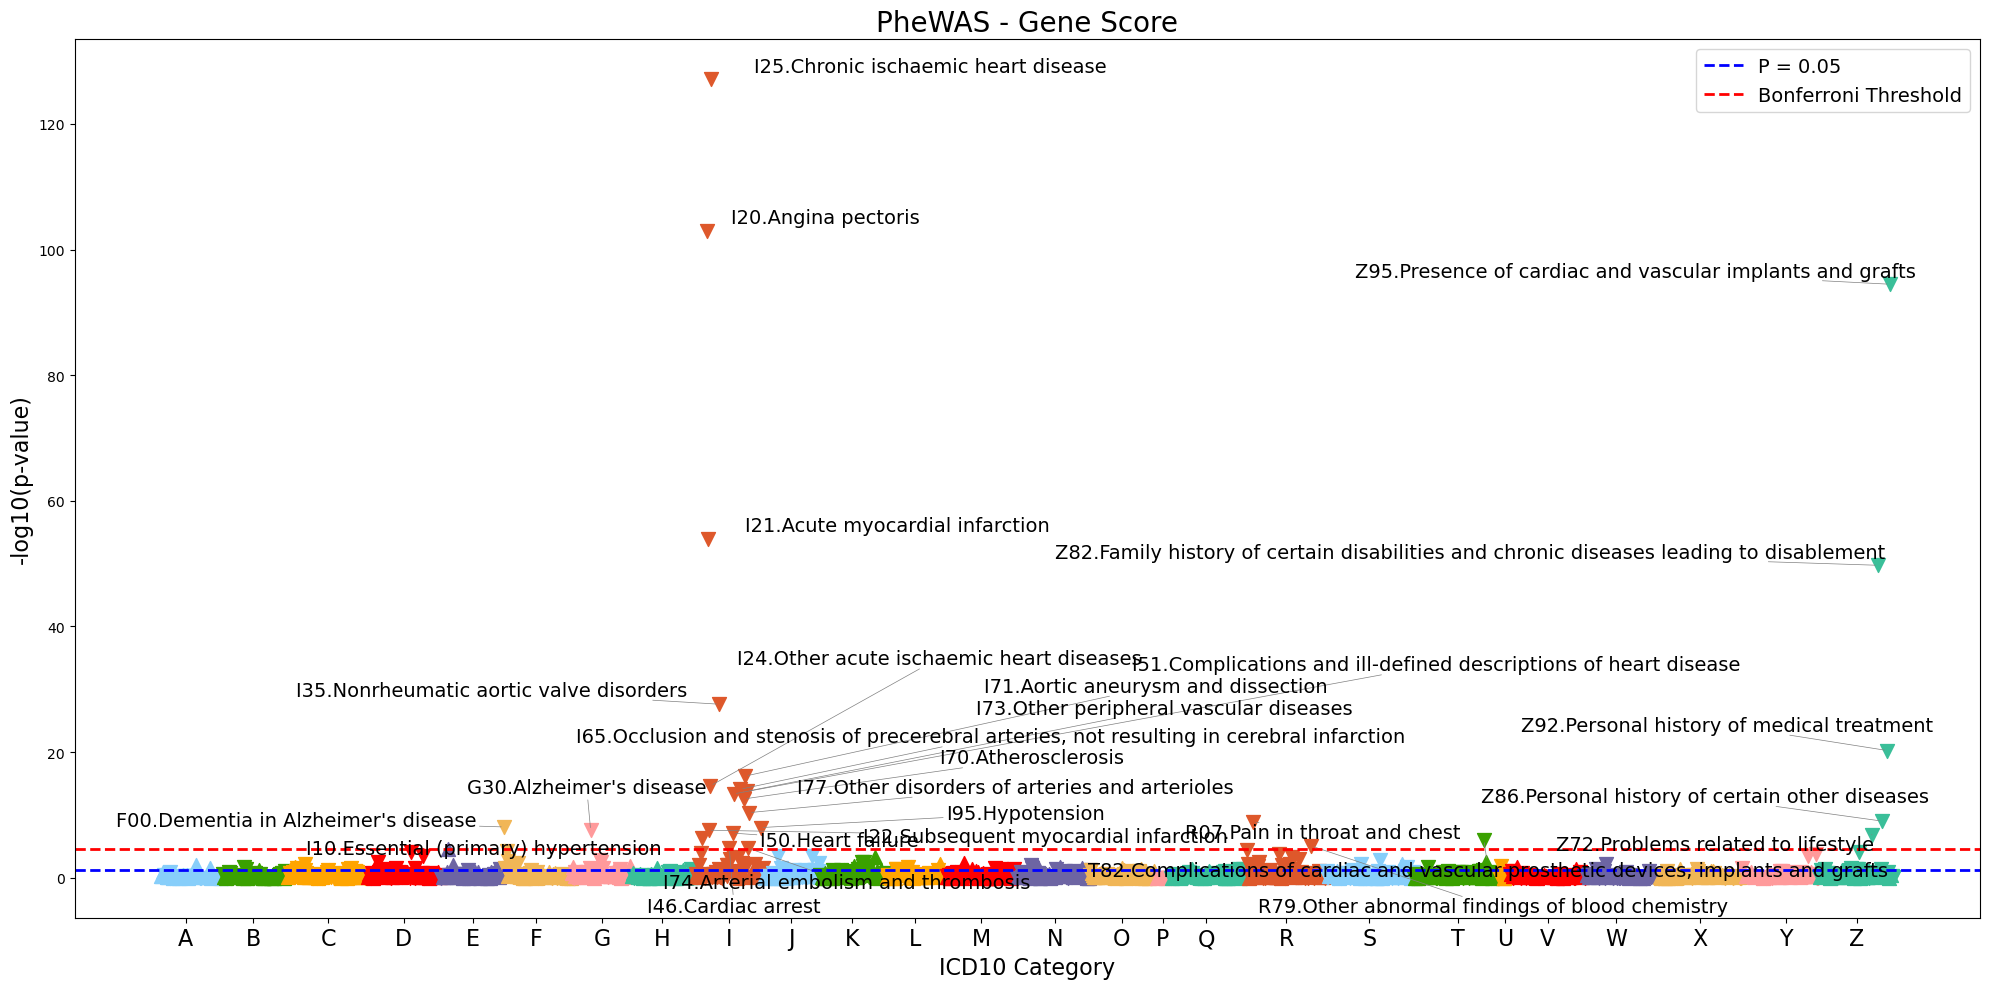

In [42]:
phewas_manhattan(joint2, "PheWAS - Gene Score")

In [3]:
joint2.head()

,Trait,beta,se,p
0,Q67,-0.021738,0.268343,0.935434
1,N83,-0.028302,0.036833,0.442255
2,C93,0.115961,0.294601,0.693861
3,M25,0.018770,0.020072,0.349698
4,Q60,0.094709,0.184768,0.608242


In [4]:
# a = [i[0] for i in joint['Trait'].tolist()]
# joint[joint['Trait'].str.startswith('Q')].shape
joint1.shape, joint2.shape
# joint.shape

((1939, 4), (1939, 4))

In [ ]:
def phewas_manhattan(df, title, ldl = False, save=False, cols=['Trait', 'beta', 'p'], p_thresh=0.05, bonferroni=True, figsize=(20, 10)):
    trait_col, beta_col, p_col = cols
    results = df[[trait_col, beta_col, p_col]].copy()
    results.columns = ['Pheno', 'beta', 'pvalue']

    results['Pheno_category'] = results['Pheno'].str.extract(r'([A-Z])')[0] 
    results['Pheno_numeric'] = results['Pheno'].str.extract(r'(\d+)').astype(float)

    results = results.sort_values(by=['Pheno_category', 'Pheno_numeric'])

    results['x_position'] = np.arange(len(results))

    colors = ['#87CEFA', '#3AA100', '#FFA500', '#FF0000', '#6D65A3', '#F1B656', '#FF9A9B', '#3abf99', '#DE582B']

    unique_categories = results['Pheno_category'].unique()
    category_to_color = {category: colors[i % len(colors)] for i, category in enumerate(unique_categories)}

    plt.figure(figsize=figsize)

    if bonferroni:
        bonferroni_threshold = p_thresh / len(results)

    for i, row in results.iterrows():
        marker = '^' if row['beta'] > 0 else 'v' 
        color = category_to_color[row['Pheno_category']]
        plt.scatter(row['x_position'], -np.log10(row['pvalue']), marker=marker, color=color, s=140)
    if bonferroni:
        plt.axhline(-np.log10(bonferroni_threshold), color='red', linestyle='--', linewidth=2, label='Bonferroni Threshold')

    x_ticks = results.groupby('Pheno_category')['x_position'].median()
    plt.xticks(x_ticks, x_ticks.index, fontsize=18)
    if ldl:
        plt.ylim(-5, 100)
        plt.yticks([0, 20,40,60,80],labels=[0, 20,40,60,80], fontsize=18)
    else:
        # plt.ylim(-5, 140)
        # plt.yticks([0, 20,40,60,80, 100, 120],labels=[0, 20,40,60,80, 100, 120], fontsize=18)
        plt.yticks(fontsize=18)

    plt.title(title, fontsize=24)
    plt.xlabel('ICD10 Category', fontsize=18)
    plt.ylabel('-log10(p-value)', fontsize=18)

    plt.legend(fontsize=18)
    plt.tight_layout()
    
    if save:
        if save.endswith('.pdf'):
            plt.savefig(save, dpi=600, bbox_inches='tight')
        else:
            plt.savefig(save, dpi=600)

    plt.show()


KeyboardInterrupt: 

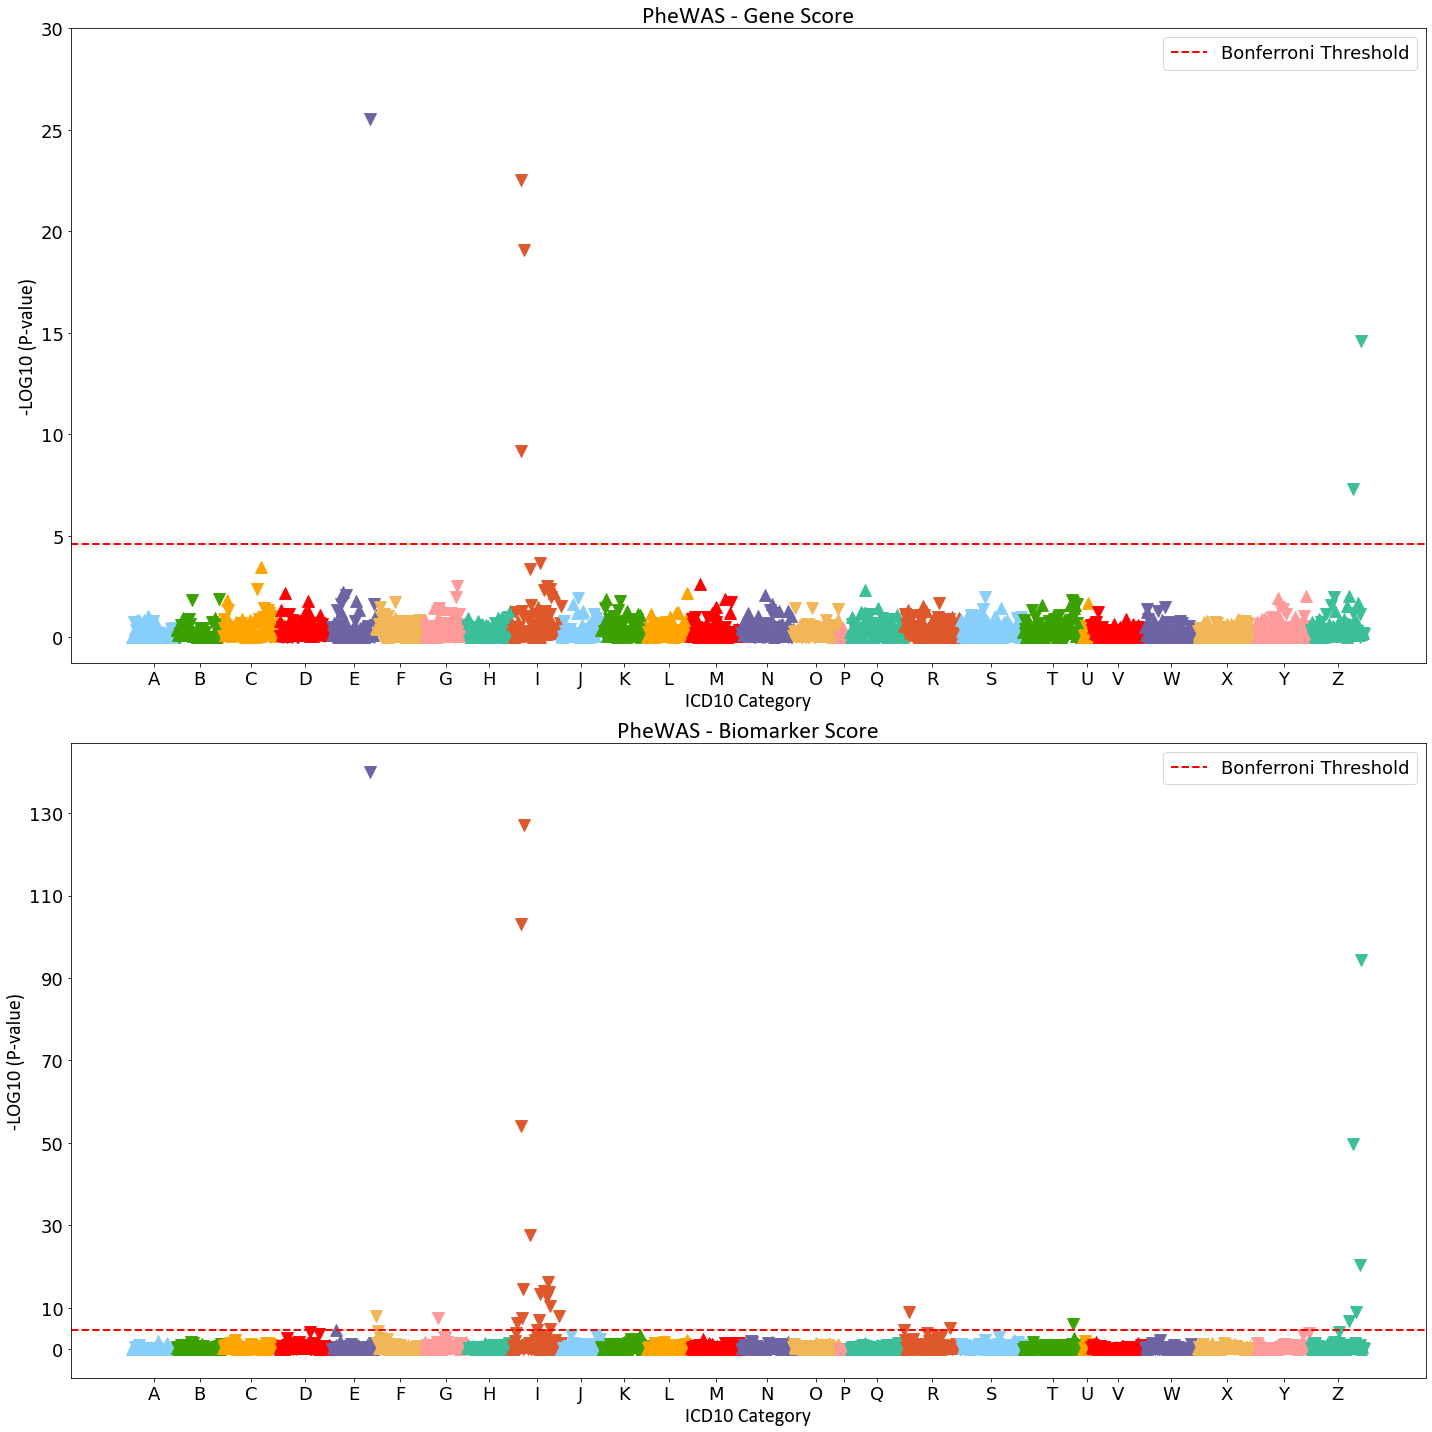

In [ ]:
from matplotlib.font_manager import FontProperties

# rcParams['font.family'] = 'sans-serif'
# rcParams['font.sans-serif'] = ['Calibri']
calibri_path = "/mnt/c/Windows/Fonts/Calibri.ttf"
custom_font = FontProperties(fname=calibri_path)

cols=['Trait', 'beta', 'p']
bonferroni_threshold = 0.05/1939

trait_col, beta_col, p_col = cols
results1 = joint1[[trait_col, beta_col, p_col]].copy()
results1.columns = ['Pheno', 'beta', 'pvalue']

results1['Pheno_category'] = results1['Pheno'].str.extract(r'([A-Z])')[0]
results1['Pheno_numeric'] = results1['Pheno'].str.extract(r'(\d+)').astype(float)

results1 = results1.sort_values(by=['Pheno_category', 'Pheno_numeric'])

results1['x_position'] = np.arange(len(results1))
results1 = results1[results1['beta'].abs() < 100].reset_index(drop=True)

colors = ['#87CEFA', '#3AA100', '#FFA500', '#FF0000', '#6D65A3', '#F1B656', '#FF9A9B', '#3abf99', '#DE582B']

unique_categories = results1['Pheno_category'].unique()
category_to_color = {category: colors[i % len(colors)] for i, category in enumerate(unique_categories)}

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(20, 20))

for i, row in results1.iterrows():
    marker = '^' if row['beta'] > 0 else 'v'
    color = category_to_color[row['Pheno_category']]
    ax[0].scatter(row['x_position'], -np.log10(row['pvalue']), marker=marker, color=color, s=140)

    # if bonferroni and row['pvalue'] <= bonferroni_threshold:
    #     plt.text(row['x_position']-10, -np.log10(row['pvalue']), row['Pheno'], fontsize=14, ha='right', va='bottom')

# ax[0].axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=2, label=f'P = {0.05}')
ax[0].axhline(-np.log10(bonferroni_threshold), color='red', linestyle='--', linewidth=2, label='Bonferroni Threshold')

x_ticks = results1.groupby('Pheno_category')['x_position'].median()
ax[0].set_xticks(x_ticks, x_ticks.index, fontsize=18)
ax[0].set_yticks([0,5,10,15,20,25,30],labels=[0,5,10,15,20,25,30],fontsize=18)
# ax[0].spines['top'].set_visible(False)
# ax[0].spines['right'].set_visible(False)
ax[0].set_title('PheWAS - Gene Score', fontsize=24, fontproperties=custom_font)
ax[0].set_xlabel('ICD10 Category', fontsize=20, fontproperties=custom_font)
ax[0].set_ylabel('-LOG10 (P-value)', fontsize=20, fontproperties=custom_font)


# ==========================================
results2 = joint2[[trait_col, beta_col, p_col]].copy()
results2.columns = ['Pheno', 'beta', 'pvalue'] 

results2['Pheno_category'] = results2['Pheno'].str.extract(r'([A-Z])')[0]
results2['Pheno_numeric'] = results2['Pheno'].str.extract(r'(\d+)').astype(float)

results2 = results2.sort_values(by=['Pheno_category', 'Pheno_numeric'])

results2['x_position'] = np.arange(len(results2))
results2 = results2[results2['beta'].abs() < 100].reset_index(drop=True)

for i, row in results2.iterrows():
    marker = '^' if row['beta'] > 0 else 'v'
    color = category_to_color[row['Pheno_category']]
    ax[1].scatter(row['x_position'], np.clip(-np.log10(row['pvalue']), a_min=None, a_max=140), marker=marker, color=color, s=140)

ax[1].axhline(-np.log10(bonferroni_threshold), color='red', linestyle='--', linewidth=2, label='Bonferroni Threshold')

x_ticks = results1.groupby('Pheno_category')['x_position'].median()
ax[1].set_xticks(x_ticks, x_ticks.index, fontsize=18)
ax[1].set_yticks([0, 10, 30, 50, 70, 90, 110, 130], labels=[0, 10, 30, 50, 70, 90, 110, 130], fontsize=18)

ax[1].set_title('PheWAS - Biomarker Score', fontsize=24, fontproperties=custom_font)
ax[1].set_xlabel('ICD10 Category', fontsize=20, fontproperties=custom_font)
ax[1].set_ylabel('-LOG10 (P-value)', fontsize=20, fontproperties=custom_font)
ax[0].legend(fontsize=18)
ax[1].legend(fontsize=18)

plt.tight_layout()
plt.savefig(root2 + 'cmb-phewas-0704.png', dpi=600)
plt.show()


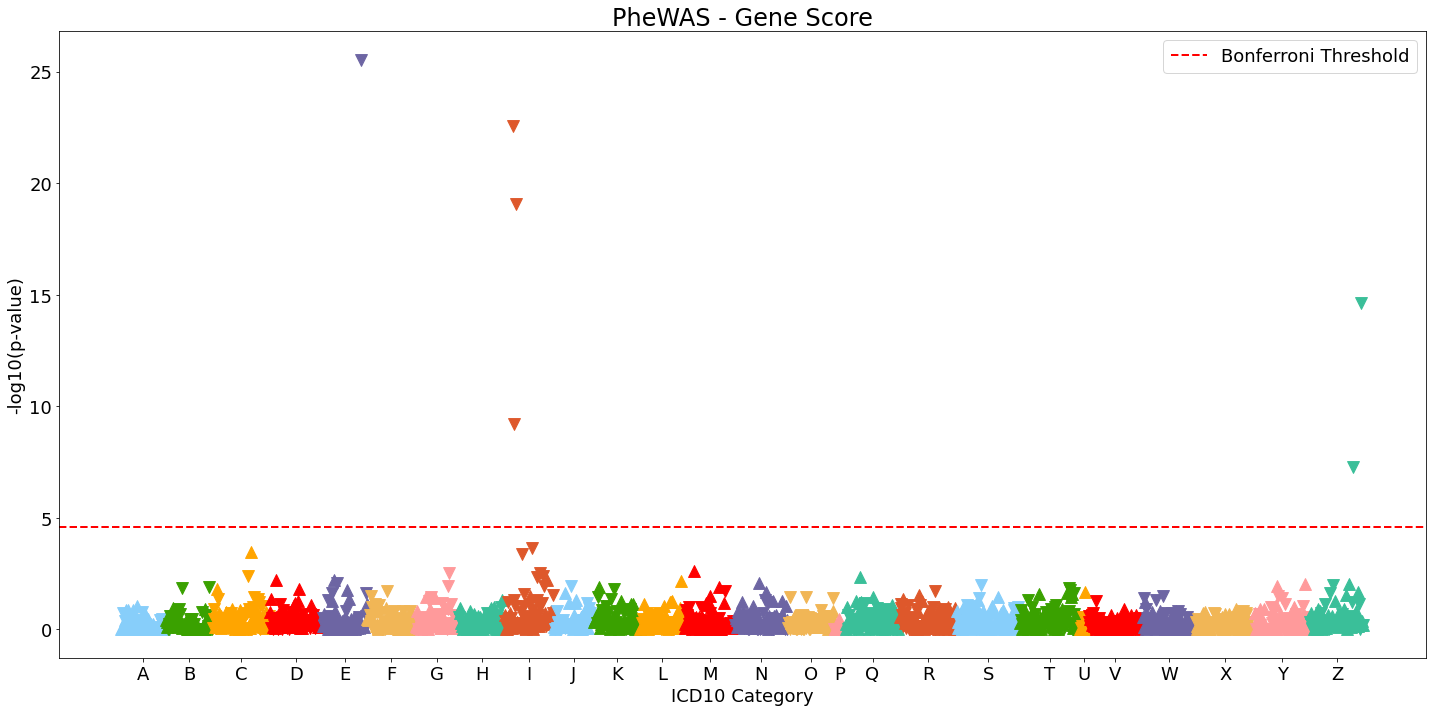

In [ ]:
phewas_manhattan(joint1, "PheWAS - Gene Score", save=root + "2x2_MR_GeneScore-cover_PheWAS_Manhattan_Plot.png")

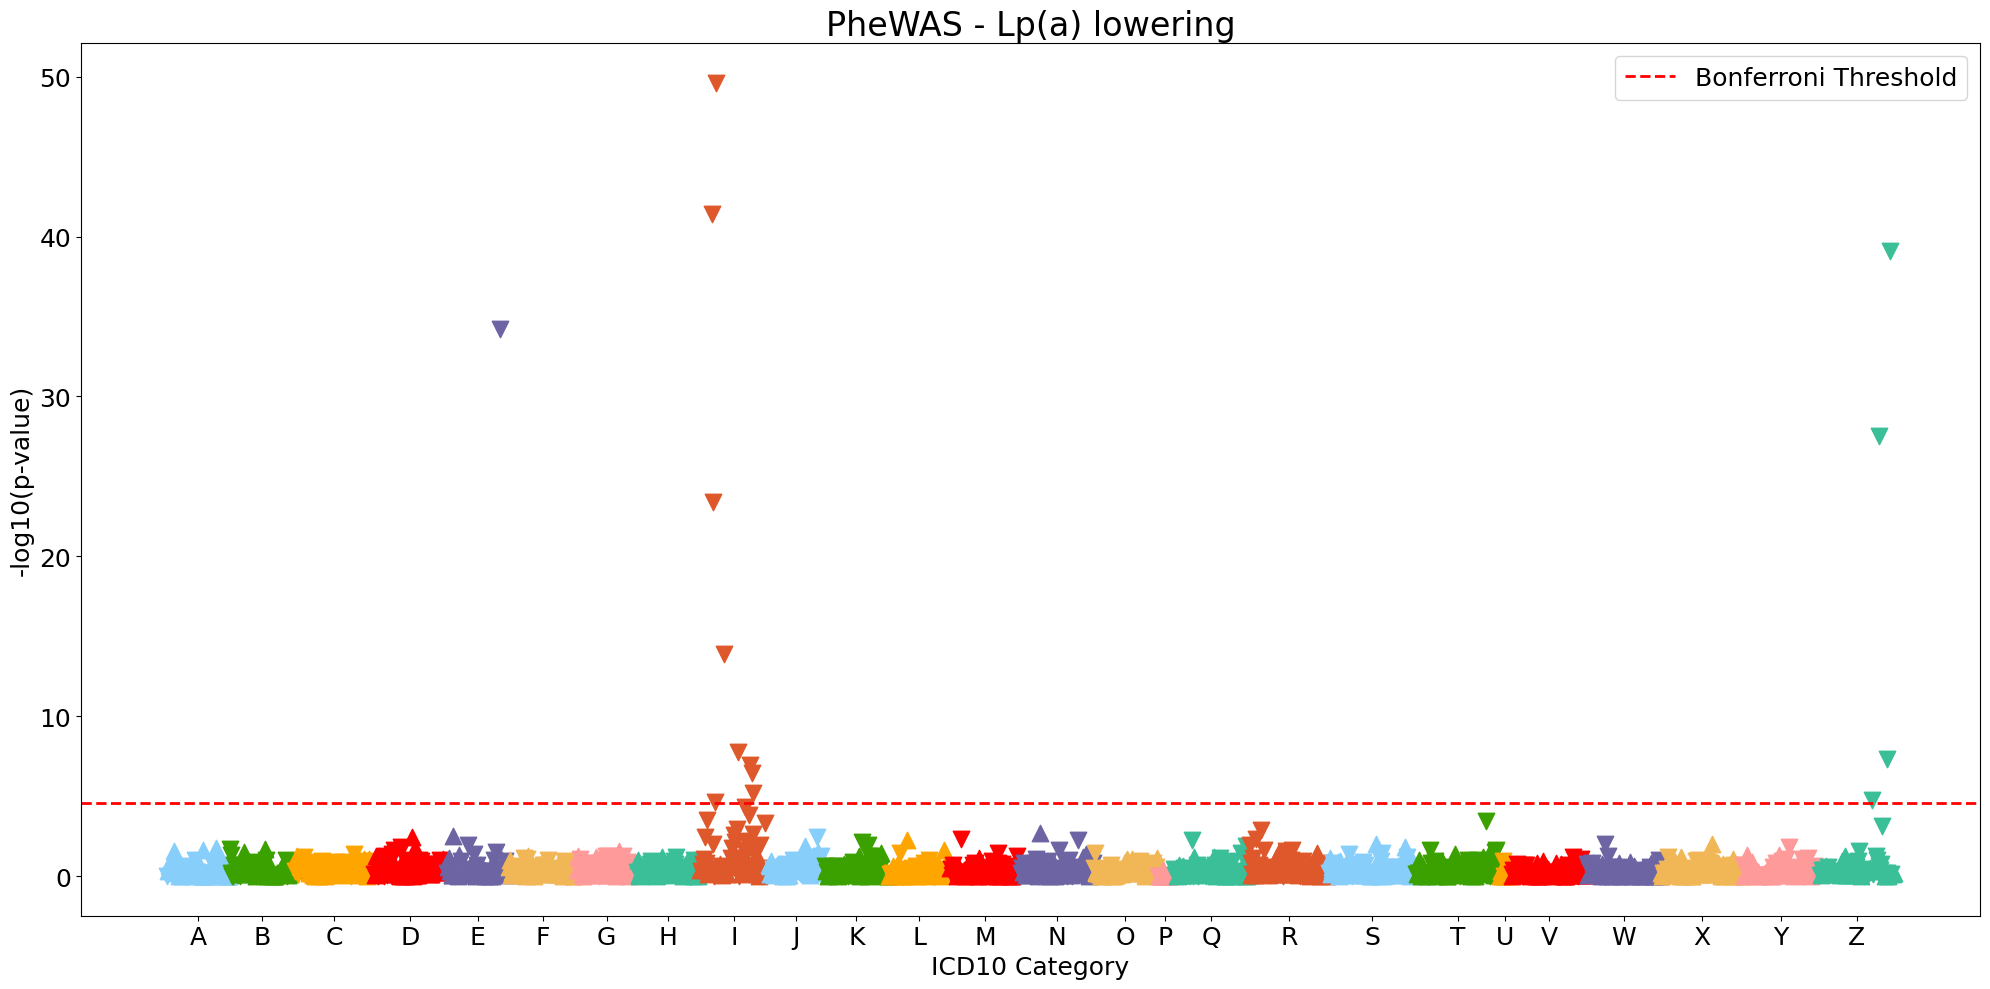

In [ ]:
phewas_manhattan(lpa, "PheWAS - Lp(a) lowering", save='/mnt/m/Lpa_phewas.pdf')

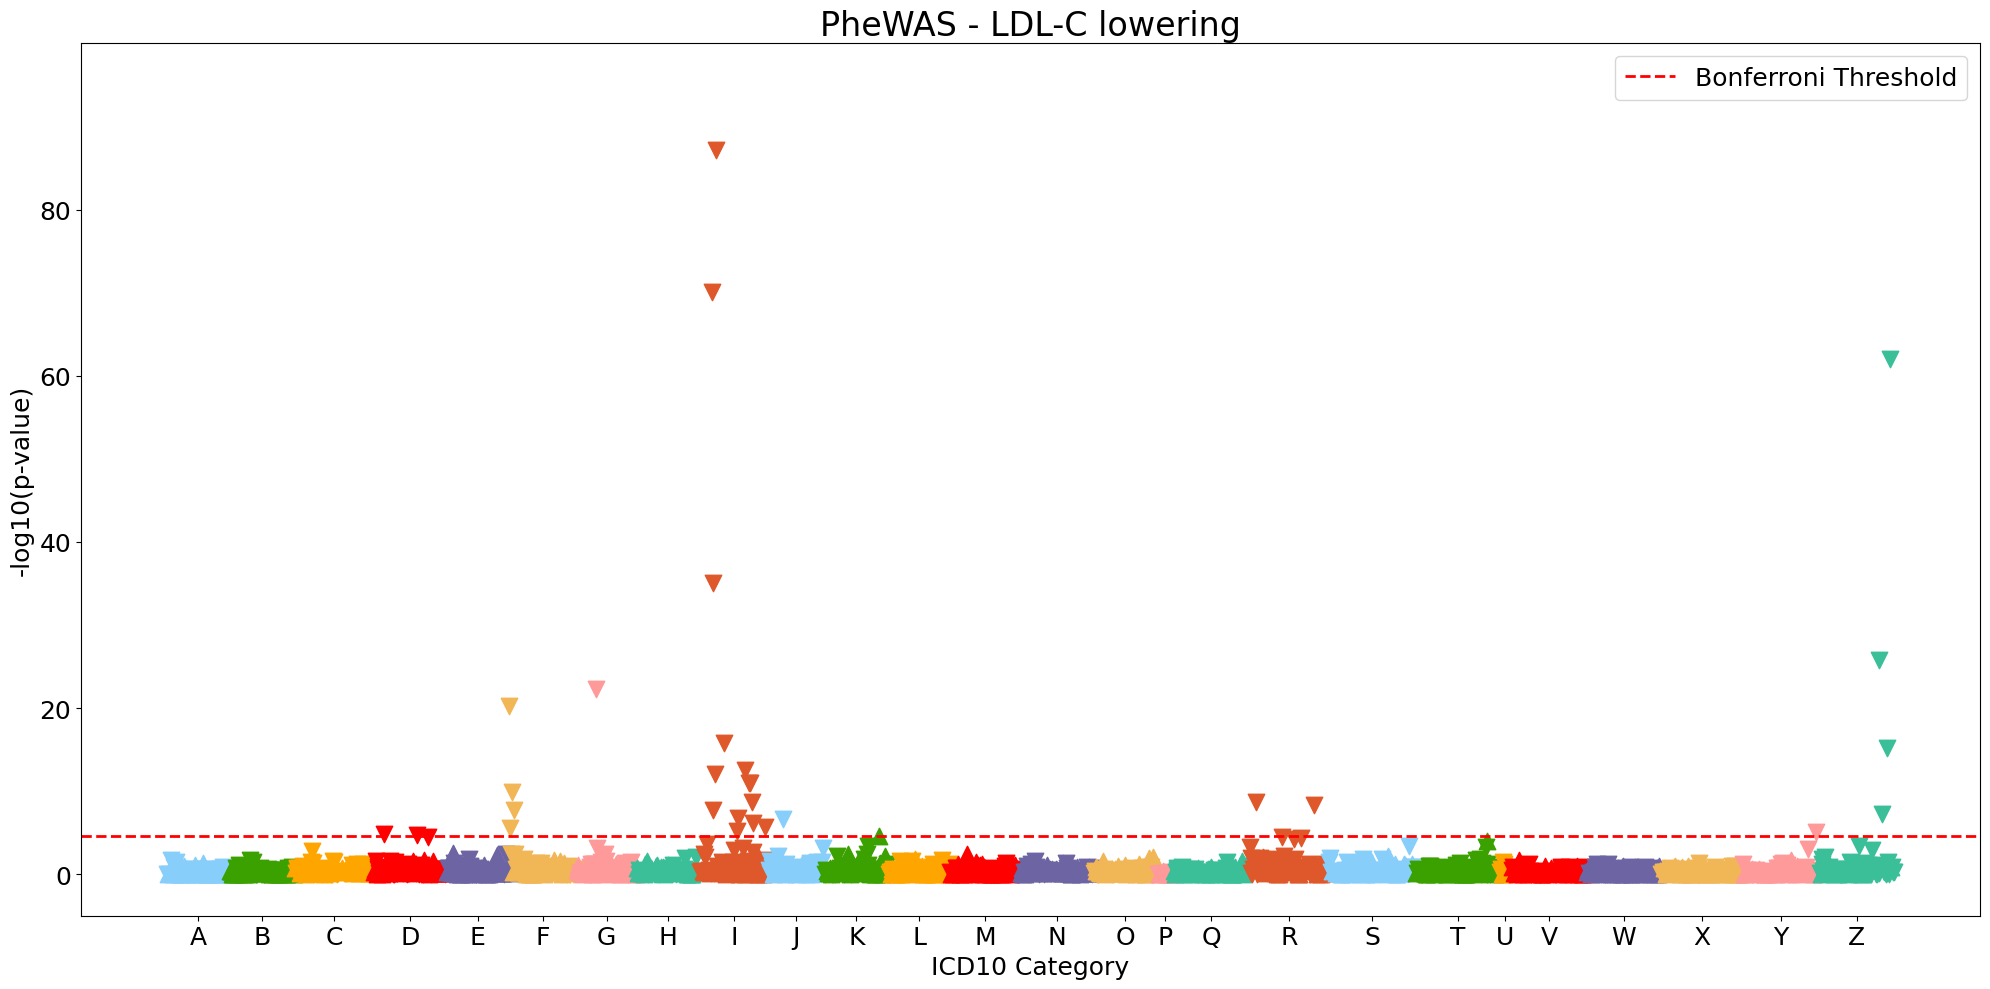

In [ ]:
phewas_manhattan(pcsk9, "PheWAS - LDL-C lowering", save=root+'Ldl_phewas.pdf', ldl=True)